In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from matplotlib import animation
from IPython.display import HTML

os.chdir("../src")
os.getcwd()

from simulator.gca import Maxflow2GCA, VesselsGCA, VesselsGCASingle

%load_ext autoreload
%autoreload 2

/home/flyingleafe/Job/Clique/simple-eigentrust/python/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def graph_node_attrs(G, *attrs):
    n = G.number_of_nodes()
    attr_arrays = {}
    for attr in attrs:
        attr_arrays[attr] = np.zeros(n)

    for node, dd in G.nodes(data=True):
        for attr in attrs:
            attr_arrays[attr][node] = getattr(dd["state"], attr)

    return attr_arrays

def graph_sequence_node_attrs(Gs, *attrs):
    dicts = [graph_node_attrs(G, *attrs) for G in Gs]
    return {
        k: np.vstack([d[k] for d in dicts])
        for k in dicts[0].keys()
    }


def graph_balances_and_credit_limits(G):
    vals = graph_node_attrs(G, 'balance', 'credit_limit')
    return vals['balance'], vals['credit_limit']

def sequence_balances_and_credit_limits(Gs):
    bss, lss = zip(*map(graph_balances_and_credit_limits, Gs))
    return np.vstack(bss), np.vstack(lss)


def plot_balances_and_credit_limits(balances, limits):
    assert len(balances) == len(limits)
    x = np.arange(len(balances))
    plt.bar(x, balances, label='Available balances')
    plt.bar(x, limits, bottom=balances, label='Credit limits')
    plt.legend()
    plt.show()


def animated_bar_plot(Xs):
    fig = plt.figure()
    T, n = Xs.shape
    barcollection = plt.bar(np.arange(n), Xs[0])

    def _animate(i):
        for j, b in enumerate(barcollection):
            b.set_height(Xs[i, j])
    
    anim = animation.FuncAnimation(fig, _animate, repeat=False,blit=False,frames=T)
    return HTML(anim.to_jshtml())

In [3]:
def simulate_and_animate(G, init_balances, n_steps=100, **kwargs):
    gca = VesselsGCA(G, balance_distribution=init_balances, **kwargs)
    records = gca.run_simulation(n_steps)

    phantom_balances = graph_sequence_node_attrs([d['graph'] for d in records[0]], 'phantom_balance')['phantom_balance']
    print(phantom_balances[-1, :])
    return phantom_balances, animated_bar_plot(phantom_balances)


def simulate_vessels(G, init_balances, n_steps=100, **kwargs):
    gca = VesselsGCA(G, balance_distribution=init_balances, **kwargs)
    records = gca.run_simulation(n_steps)

    phantom_excesses = graph_sequence_node_attrs([d['graph'] for d in records[0]], 'phantom_balance')['phantom_balance']
    print(phantom_excesses[-1, :])
    return phantom_excesses, records


def simulate_single_user_debt(G, init_balances, n_steps=100, n_user=0, **kwargs):
    gca = VesselsGCASingle(G, balance_distribution=init_balances, debting_node=n_user, **kwargs)
    records = gca.run_simulation(n_steps)

    balances = graph_sequence_node_attrs([d['graph'] for d in records[0]], 'balance')['balance']
    print(balances[-1, :])
    return balances, records

In [4]:
mini_graph = nx.DiGraph()

mini_graph.add_node(0)
mini_graph.add_node(1)

mini_graph.add_edge(0, 1, capacity=5, height=90000)

init_balances = {0: 100000, 1: 1000}

#simulate_and_animate(mini_graph, init_balances, fractional_banking_coeff=0.1)

hmm, records = simulate_single_user_debt(mini_graph, init_balances, n_user=1)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 100, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (100, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 208.38it/s]


Execution Method: single_proc_exec


Flattening results:   1%|█▎                                                                                                                                  | 1/101 [00:00<00:00, 234.76it/s]

Total execution time: 0.09s
[89998.91938382 11001.08061618]


In [5]:
def draw_with_edge_colors(G):
    ccs = [('r' if d["state"].is_open else 'k') for u, v, d in G.edges(data=True)]
    nx.draw_kamada_kawai(G, edge_color=ccs, with_labels=True)
    

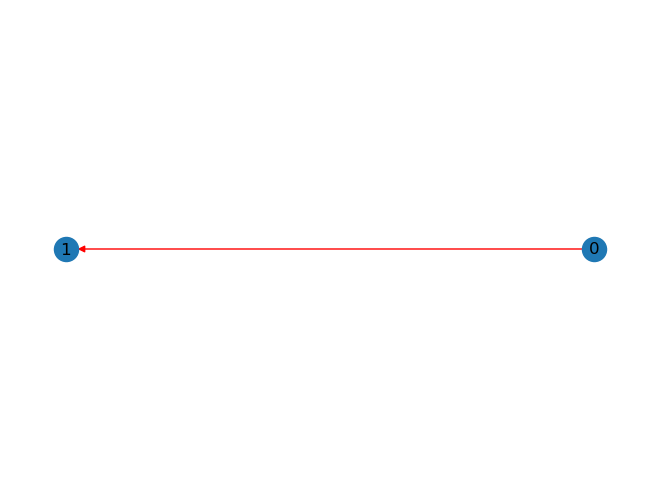

In [6]:
draw_with_edge_colors(records[0][1]['graph'])

In [7]:
def softmax(x, t=1.0):
    return np.exp(x/t)/sum(np.exp(x/t))

def generate_pareto_graph_vessels(N, total_money=1000000, avg_degree=4):
    balances = np.random.pareto(2.0, size=N)
    normalized_balances = balances / np.sum(balances)
    balances = normalized_balances * total_money

    G = nx.DiGraph()
    sorted_by_richness = np.argsort(balances)[::-1]

    for n in sorted_by_richness:
        G.add_node(n)

    for i, n in enumerate(sorted_by_richness):
        moneys = balances[n]
        degree = np.random.randint(avg_degree-2, avg_degree+2)

        mean_height = 0.5 * moneys
        sigma_height = 0.2 * mean_height

        others = np.concatenate([sorted_by_richness[:i], sorted_by_richness[i+1:]])
        assert len(others) == N-1
        other_balances = balances[others]

        closeness_in_richness = np.abs(other_balances - moneys) + 0.1
        p = softmax(1 / closeness_in_richness, t=2.0)

        out_neighbors = np.random.choice(others, size=degree, p=p, replace=False)

        for other in out_neighbors:
            G.add_edge(
                n, other,
                capacity=N*normalized_balances[n],
                height=(sigma_height*np.random.rand() + mean_height)
            )
    
    return G, balances

def plot_timeframes(res, timeframes):
    N = len(timeframes)
    xs = np.arange(results.shape[1])
    orig = res[0]
    
    fig, axes = plt.subplots(nrows=N, ncols=1, figsize=(10, 2*N))

    for i in range(N):
        frame = timeframes[i]
        plt.sca(axes[i])
        plt.bar(xs, results[0], alpha=0.5)
        plt.bar(xs, results[frame], alpha=0.5)
        plt.title(f"Time step {frame}")

    fig.tight_layout()
    plt.show()


# tak blyat

In [9]:
mini_graph = nx.DiGraph()

mini_graph.add_node(0)
mini_graph.add_node(1)
mini_graph.add_node(2)
mini_graph.add_node(3)
mini_graph.add_node(4)

mini_graph.add_edge(0, 1, capacity=5, height=60000)
mini_graph.add_edge(1, 2, capacity=5, height=30000)
mini_graph.add_edge(2, 3, capacity=5, height=10000)
mini_graph.add_edge(3, 4, capacity=5, height=5000)

init_balances = {0: 100000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}

#simulate_and_animate(mini_graph, init_balances, fractional_banking_coeff=0.1)

hmm, records = simulate_single_user_debt(mini_graph, init_balances, n_user=4)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 100, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (100, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 401.95it/s]


Execution Method: single_proc_exec


Flattening results:   1%|█▎                                                                                                                                  | 1/101 [00:00<00:00, 243.12it/s]

Total execution time: 0.10s
[59997.01545475 29995.76188647  9994.18789642  3013.03476236
  1000.        ]


<BarContainer object of 5 artists>

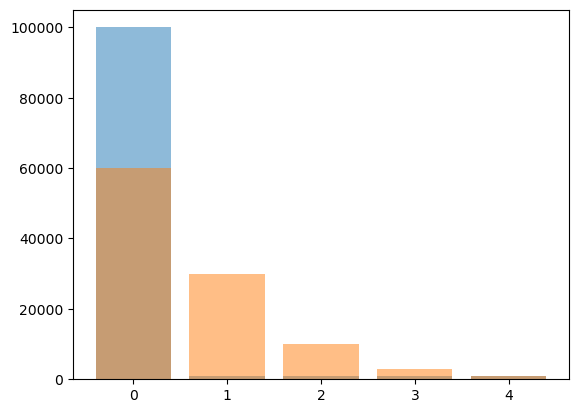

In [10]:
plt.bar(np.arange(hmm.shape[1]), hmm[0], alpha=0.5)
plt.bar(np.arange(hmm.shape[1]), hmm[-1], alpha=0.5)

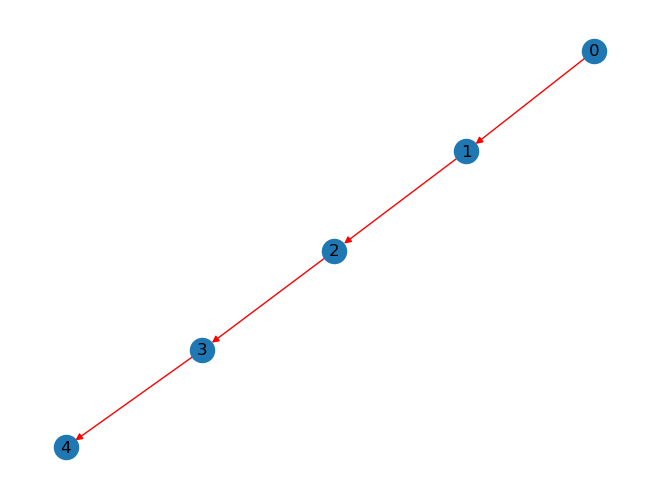

In [11]:
draw_with_edge_colors(records[0][4]['graph'])

In [12]:
G, balances = generate_pareto_graph_vessels(100)

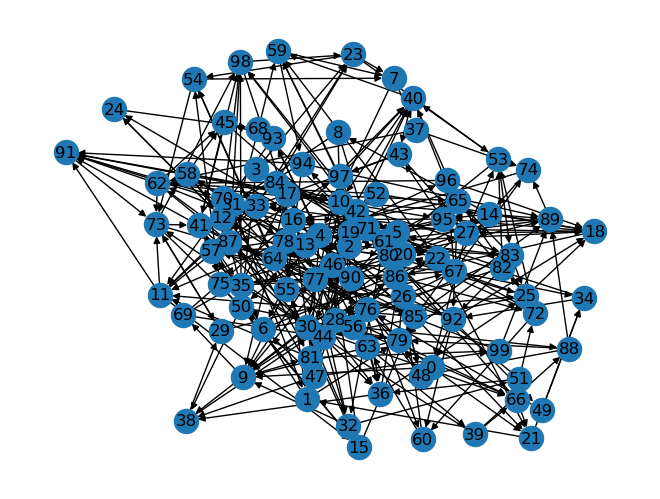

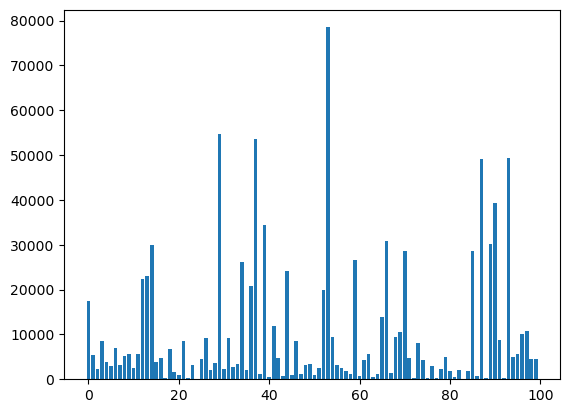

1000000.0000000002


In [13]:
nx.draw(G, with_labels=True)
plt.show()
plt.bar(np.arange(len(balances)), balances)
plt.show()
print(np.sum(balances))

In [14]:
balances_dict = {n: balances[n] for n in range(len(balances))}

In [15]:
results, records = simulate_vessels(G, balances_dict, n_steps=500)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 457.00it/s]

Execution Method: single_proc_exec



Flattening results:   0%|▎                                                                                                                                   | 1/501 [00:00<00:01, 433.83it/s]

Total execution time: 9.19s
[ 9075.31896756  7917.28326959  7050.22715595  8092.01789991
  8060.18615997  7122.40272306  8075.06532511  8087.01750138
  7713.08897569  8082.73401913  8102.93750589  8082.44497877
 12355.85337384 11489.39129594 15517.38245994  8081.01041957
  8098.0546999   8432.43344729  7856.76870305  8108.0710003
  8054.23225288  7917.66809791  8108.31306341  8091.58457803
  6879.47197292  7793.73865573  8063.77963024  7804.38194588
  8102.58800774 28384.7971817   8070.39072737  7925.86902269
  7931.25579303  6416.79467072 14565.81231991  8077.61688603
 10630.69900592 29163.08263392  8114.4991284  18982.02942479
  8425.26360192  8074.01480138  8083.01655116  7516.7902834
 12890.18711643  8111.30833679  8082.26453262  8086.69105233
  6928.11924155  7714.61389684  8092.34344399  7930.9955305
  9996.39651744 39479.94250482  8088.78090426  8088.21466329
  7922.77021157  7820.62649217  8109.50604899 14679.52999506
  6846.21029677  7915.05199681  8084.5469601   6329.5749712


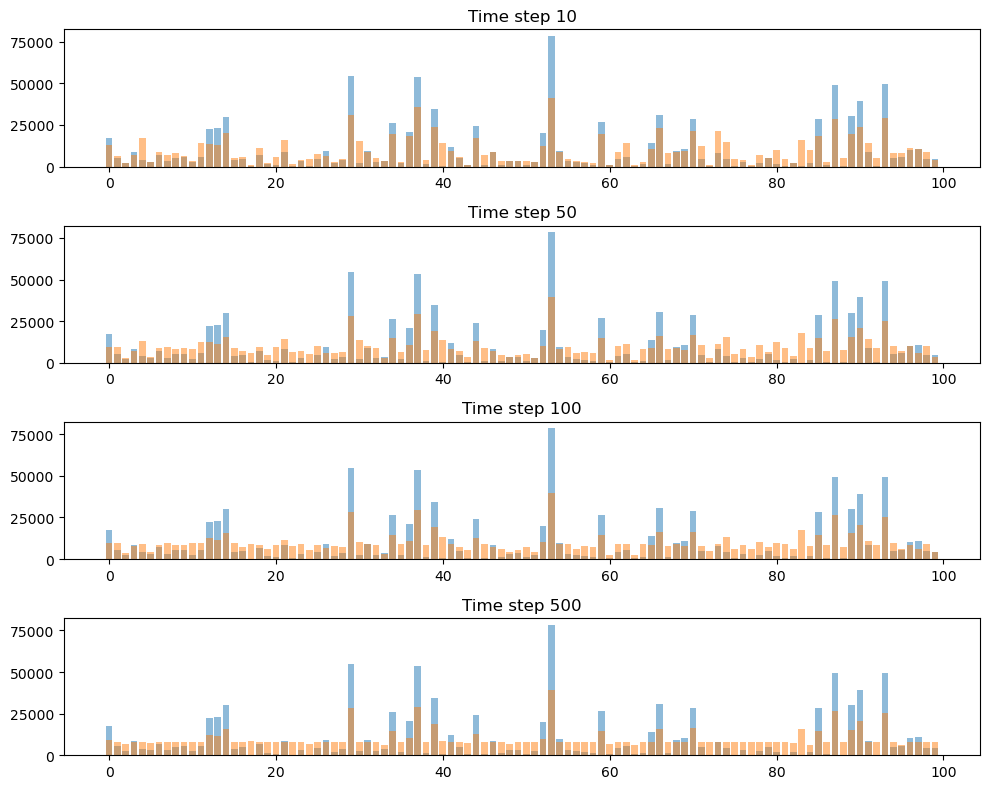

In [17]:
plot_timeframes(results, [10, 50, 100, 500])

In [41]:
results, records = simulate_single_user_debt(G, balances_dict, n_steps=100, n_user=0)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 100, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (100, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 728.81it/s]

Execution Method: single_proc_exec



Flattening results:   1%|█▎                                                                                                                                  | 1/101 [00:00<00:00, 585.39it/s]

Total execution time: 1.67s
[17427.64727714  9634.46991771  2028.90072341  4909.37496078
 16520.2559048   2159.12995757  8228.80634704  9607.12338996
  7991.34174966  4486.51932019  9076.85311034 10007.71221093
 12354.57461903 11490.48363711 15514.28547596 10194.49335244
  5807.30974033  8640.03219553  7562.57065679  4059.52428492
  9741.84759631 11623.45728247  7272.28117248  8069.19523428
  5066.64490506  8657.93990382  5222.98646513  7318.95431056
  6067.28651495 28376.11564626 15363.71812949  7882.84508704
  8950.73477429  2116.85650853 14567.31465616  4043.22668286
 10631.9209659  29161.13379282  8923.02025711 18978.64140495
 16961.96605681  6585.91358954  5151.90156205  4859.93115018
 12889.52352114  9734.14105492  5204.98764083  5682.83169311
  3197.51457517  3352.07322517  3687.58239133  4354.2430078
  9995.66016329 39480.25042392  8384.53783885  9685.96938579
  5419.61491669  9516.47376055  6346.33889521 14679.52999506
  1583.60411972  9853.01423899  9269.14591017  1953.184952

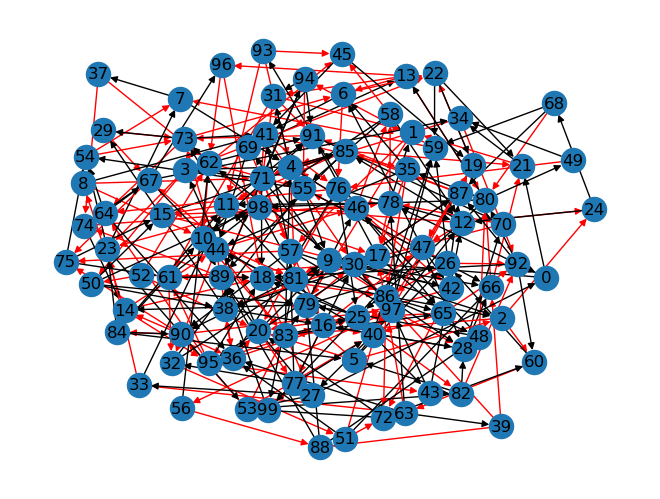

In [42]:
draw_with_edge_colors(records[0][-1]['graph'])

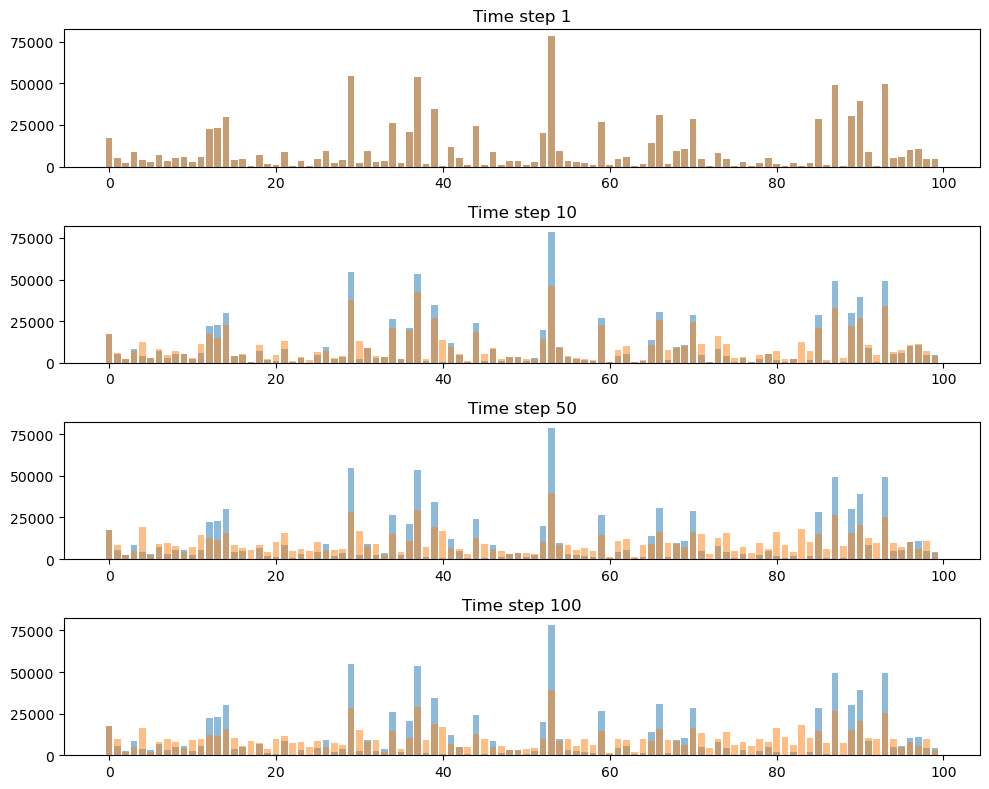

In [43]:
plot_timeframes(results, [1, 10, 50, 100])

In [ ]:
all_results = []

max_debt_results = np.zeros((101, 100))

for n_user in range(100):
    print("USER", n_user)
    results, records = simulate_single_user_debt(G, balances_dict, n_steps=100, n_user=n_user)
    all_results.append(results)
    max_debt_results[:, n_user] = results[:, n_user]

USER 0

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 100, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (100, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 770.73it/s]

Execution Method: single_proc_exec



Flattening results:   1%|█▎                                                                                                                                  | 1/101 [00:00<00:00, 604.19it/s]


Total execution time: 2.04s
[17427.64727714  9634.46991771  2028.90072341  4909.37496078
 16520.2559048   2159.12995757  8228.80634704  9607.12338996
  7991.34174966  4486.51932019  9076.85311034 10007.71221093
 12354.57461903 11490.48363711 15514.28547596 10194.49335244
  5807.30974033  8640.03219553  7562.57065679  4059.52428492
  9741.84759631 11623.45728247  7272.28117248  8069.19523428
  5066.64490506  8657.93990382  5222.98646513  7318.95431056
  6067.28651495 28376.11564626 15363.71812949  7882.84508704
  8950.73477429  2116.85650853 14567.31465616  4043.22668286
 10631.9209659  29161.13379282  8923.02025711 18978.64140495
 16961.96605681  6585.91358954  5151.90156205  4859.93115018
 12889.52352114  9734.14105492  5204.98764083  5682.83169311
  3197.51457517  3352.07322517  3687.58239133  4354.2430078
  9995.66016329 39480.25042392  8384.53783885  9685.96938579
  5419.61491669  9516.47376055  6346.33889521 14679.52999506
  1583.60411972  9853.01423899  9269.14591017  1953.184952

Initializing configurations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 613.47it/s]


Execution Method: single_proc_exec


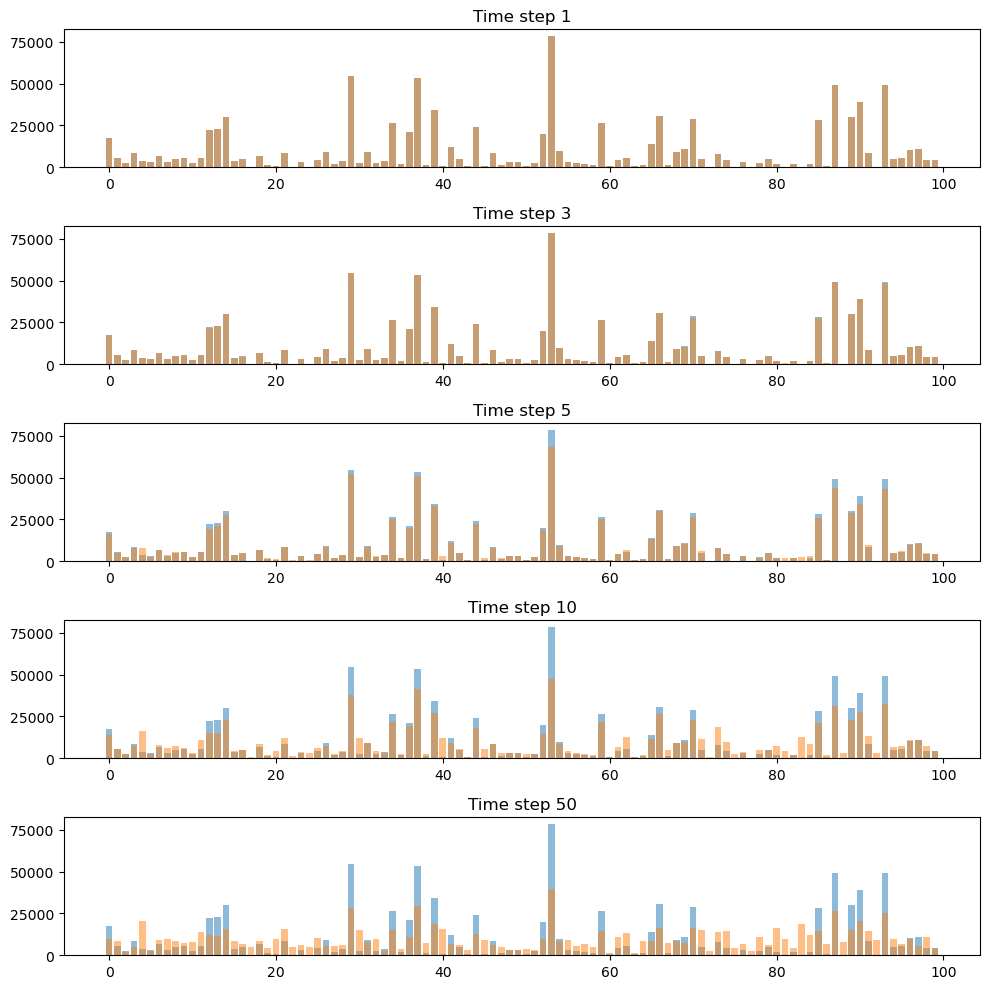

In [45]:
plot_timeframes(max_debt_results, [1, 3, 5, 10, 50])

In [56]:
max_debt_results[:, ]

array([14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
      

In [64]:
results, records = simulate_single_user_debt(G, balances_dict, n_steps=500, n_user=20)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 775.14it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                    | 1/501 [00:00<00:00, 692.36it/s]

Total execution time: 7.00s
[14967.49144613  1945.98376163 28317.43151992  1282.92334932
  9270.36663056 26879.50735188 14584.96612529 39078.66761589
 29332.7229064   1639.5056298   8034.59529383  6712.18293188
   625.10440365   601.6565741  27171.37071556 54056.24727251
  2009.51110011  5419.89029287 10080.80510241  4417.49249181
 40633.04920214  3241.76750961  6811.16596031 30425.17106213
  8252.9420818    618.86780837   924.11530241  4393.80322318
  5105.90840489  5860.44500788 40252.53666382 31894.82479964
  6593.98764334  3778.96506597   278.82547257 11469.15653081
    95.44765316  2753.0455115   6330.34545118  4395.90445477
  1391.56701229 20411.25753441  4555.70145304   386.11878907
 32241.14386103  9321.29594657  6116.59611688 14574.93053317
 12512.21852042  3016.68303062   702.02466713  1038.11980826
   932.9254273  17032.18041678  2224.76995301 24980.87344801
  5123.12146989  7830.45299664  3100.26474239  6433.70764237
  3242.30616053  6345.72602294  3813.8863854   9568.44390

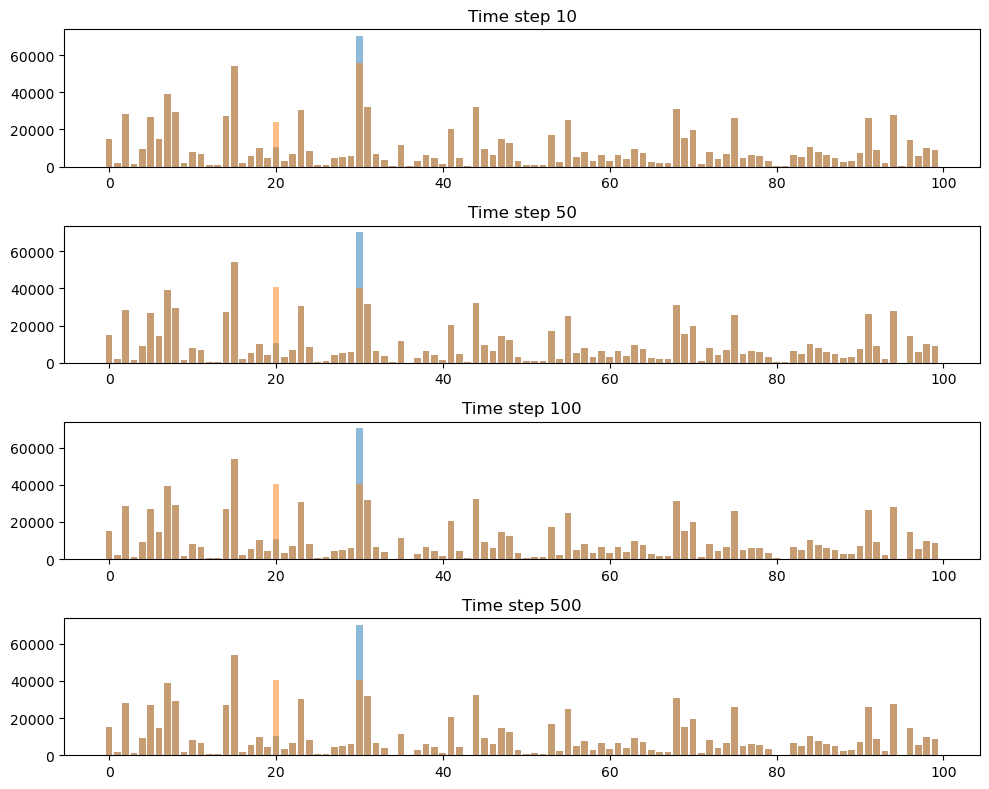

In [65]:
plot_timeframes(results, [10, 50, 100, 500])

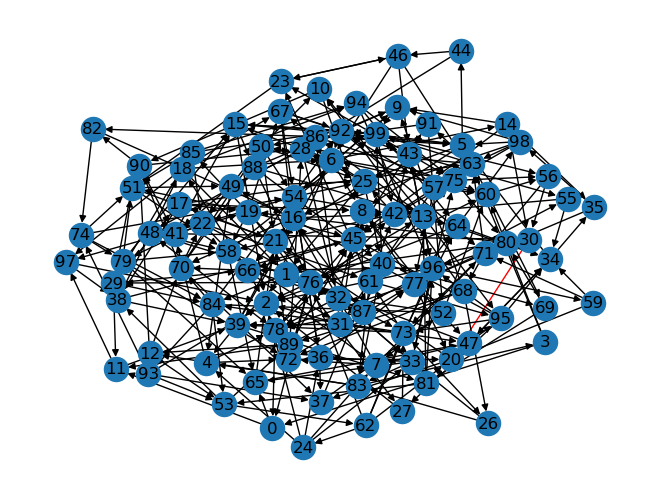

In [66]:
draw_with_edge_colors(records[0][-1]['graph'])

In [57]:
results[0][20]

44121491.25260995

In [66]:
all_results = []
for i in range(30):
    results, records = simulate_single_user_debt(G, balances_dict, n_steps=500, n_user=i)
    all_results += [(results, records)]


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 561.86it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                    | 1/501 [00:00<00:00, 681.89it/s]


Total execution time: 1.70s
[5.49347694e+07 3.83500641e+06 1.72629192e+07 8.63701791e+07
 1.28998226e+07 1.19876336e+07 2.22819875e+07 9.98627790e+04
 5.40257298e+07 3.46675534e+07 2.36588122e+06 2.11108037e+07
 1.15466266e+08 2.29029603e+08 1.08767697e+06 7.80506095e+05
 2.86165250e+07 1.92511806e+07 1.15975581e+07 4.33347541e+07
 4.41214913e+07 5.31444811e+06 1.43599477e+07 1.31973878e+07
 3.05625465e+07 4.04265212e+07 2.33309290e+07 4.97908852e+07
 9.58073994e+05 6.86618475e+06]

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


...

Total execution time: 1.92s
[7.26262487e+06 3.83500641e+06 1.72629192e+07 6.73987899e+07
 1.28998226e+07 1.19876336e+07 3.62835745e+07 9.98627790e+04
 4.46410287e+07 4.05854679e+07 2.36588122e+06 2.33729690e+07
 9.50417325e+07 2.37619592e+08 1.08767697e+06 7.80506095e+05
 3.78791066e+07 1.92511806e+07 1.15975581e+07 3.65202755e+07
 3.71396117e+07 4.01363155e+07 1.43599477e+07 1.31973878e+07
 3.93458250e+07 4.07728806e+07 2.33309290e+07 3.74422638e+07
 3.93674684e+07 6.86618475e+06]

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 648.07it/s]


Execution Method: single_proc_exec


Flattening results:   0%|                                    | 1/501 [00:00<00:00, 535.81it/s]

Total execution time: 1.84s
[7.26262487e+06 3.83500641e+06 1.72629192e+07 6.74055429e+07
 1.28998226e+07 1.19876336e+07 2.22819875e+07 9.98627790e+04
 4.50075063e+07 4.14950276e+07 2.36588122e+06 2.37979522e+07
 9.50579853e+07 2.74079965e+08 1.08767697e+06 7.80506095e+05
 3.89903861e+07 1.92511806e+07 1.15975581e+07 3.75708454e+07
 3.83450045e+07 5.31444811e+06 1.43599477e+07 1.31973878e+07
 3.77480277e+07 4.16606136e+07 3.55525326e+07 4.97908852e+07
 9.58073994e+05 2.87473738e+07]


In [67]:
len(all_results)

30

In [68]:
max_debts = np.zeros(30)
for i, (res, rec) in enumerate(all_results):
    max_debts[i] = res[-1][i]
    

<BarContainer object of 30 artists>

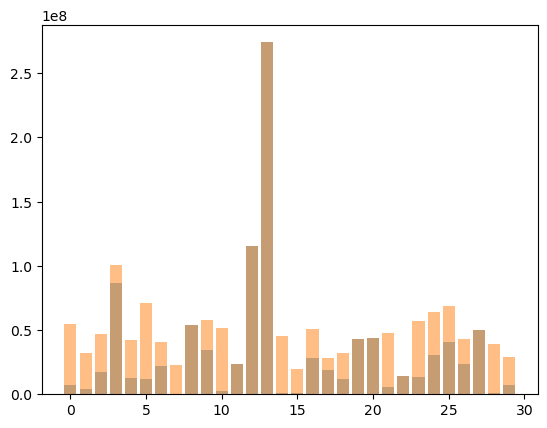

In [69]:
plt.bar(np.arange(max_debts.shape[0]), results[0], alpha=0.5)
plt.bar(np.arange(max_debts.shape[0]), max_debts, alpha=0.5)

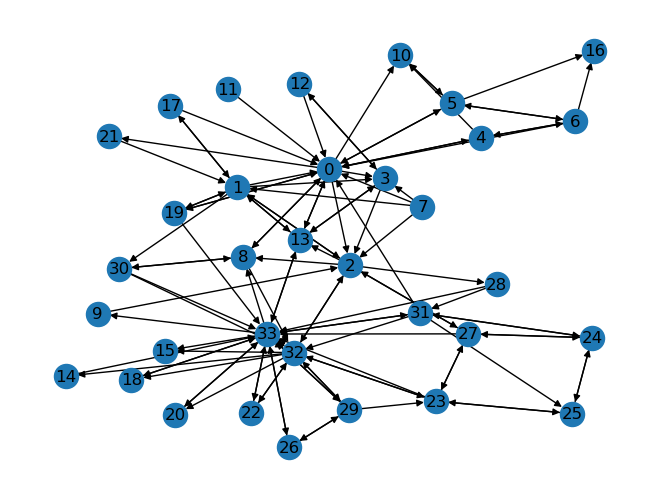

In [162]:
karate_graph = nx.karate_club_graph()

G_dir = karate_graph.to_directed()

for n in G_dir.nodes:
    neighbors = list(set(G_dir.successors(n)) | set(G_dir.predecessors(n)))
    for other in neighbors:
        if (n, other) in G_dir.edges and (other, n) in G_dir.edges:
            p = np.random.rand()
            if p < 0.2:
                G_dir.remove_edge(n, other)
            elif p < 0.4:
                G_dir.remove_edge(other, n)

for u, v, d in G_dir.edges(data=True):
    G_dir.edges[u, v]["capacity"] = d["weight"]
    del G_dir.edges[u, v]["weight"]

nx.draw_kamada_kawai(G_dir, with_labels=True)

In [163]:
balances = np.random.pareto(2.0, size=G_dir.number_of_nodes())
balances = balances / np.sum(balances) * 1000000


<BarContainer object of 34 artists>

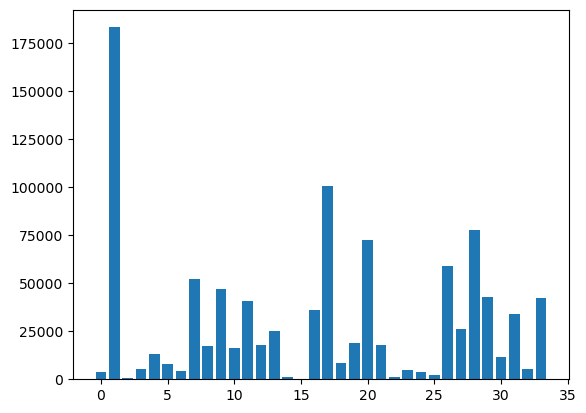

In [164]:
plt.bar(np.arange(len(balances)), balances)

In [165]:
heights_low = balances * 0.3
heights_hi = balances * 1.1

for node in G_dir.nodes:
    for other in G_dir.successors(node):
        G_dir.edges[node, other]["height"] = np.random.uniform(heights_low[node], heights_hi[node])

In [166]:
list(G_dir.edges(data=True))[:4]

[(0, 2, {'capacity': 5, 'height': 3947.6044220784706}),
 (0, 3, {'capacity': 3, 'height': 3464.4610134448367}),
 (0, 4, {'capacity': 3, 'height': 2759.5830543325237}),
 (0, 5, {'capacity': 3, 'height': 4319.300700385576})]

In [167]:
balances_dict = {i: balances[i] for i in range(len(balances))}

In [180]:
results = simulate_vessels(G_dir, balances_dict, n_steps=1000, fractional_banking_coeff=0.9)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 1000, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (1000, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 509.51it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                   | 1/1001 [00:00<00:01, 644.78it/s]

Total execution time: 5.85s
[32683.22238897 32707.12253689 33017.37685472 32705.47100199
 32856.44036842 32943.59545405 32732.04477973 29830.6797107
 32987.99981247 33249.77521143 32784.86260764 29840.76539659
 32762.65839211 33134.62335061 32791.08986707 33639.48367176
 35805.70187776 32816.16223854 33126.23574049 32840.22515198
 32924.51055014 32768.78814734 32825.13984046 33121.1901732
 32796.17202189 32769.90648947 33009.45813978 32807.91230925
 32745.10189594 33117.12328197 32712.0069788  33081.01991271
 32734.98662172 32690.62856469]


<BarContainer object of 34 artists>

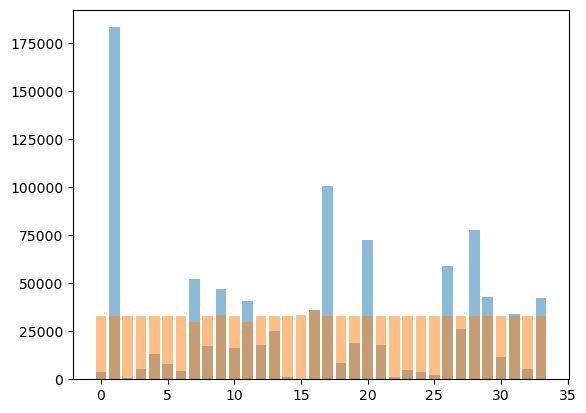

In [181]:
plt.bar(np.arange(results.shape[1]), results[0], alpha=0.5)
plt.bar(np.arange(results.shape[1]), results[-1], alpha=0.5)

In [182]:
print(list(G_dir.predecessors(0)))

results, records = simulate_single_user_debt(G_dir, balances_dict, n_steps=1500, n_user=3)

[1, 4, 5, 6, 7, 8, 11, 12, 13, 17, 19, 31]

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 1500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (1500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 826.79it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                   | 1/1501 [00:00<00:02, 698.93it/s]

Total execution time: 5.81s
[  3958.69134583  94154.33895878    783.31664741  94214.89472135
  13292.20013606   8167.75276644   4453.16269363  52215.87989912
  17227.11710049  46877.55692727  16008.27019095  40548.03057243
  17882.30241454  24860.52930703   1094.58948776    271.36239919
  35805.70187776 100340.87773531   8568.59889548  18783.50669494
  72279.77261245  17665.52094961   1291.94200979   4919.67625454
   3532.70558462   2396.9117051   58814.50161316  26210.821425
  77683.14901914  42697.76856059  11328.43183998  33931.38353554
   5580.50817485  42158.22594383]


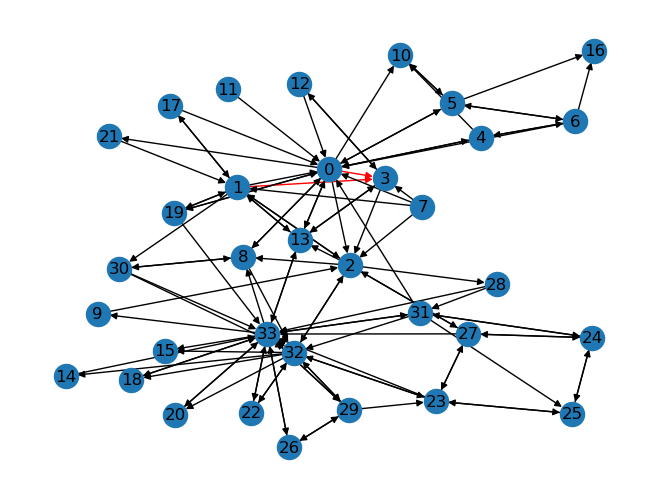

In [183]:
draw_with_edge_colors(records[0][-1]['graph'])

<BarContainer object of 34 artists>

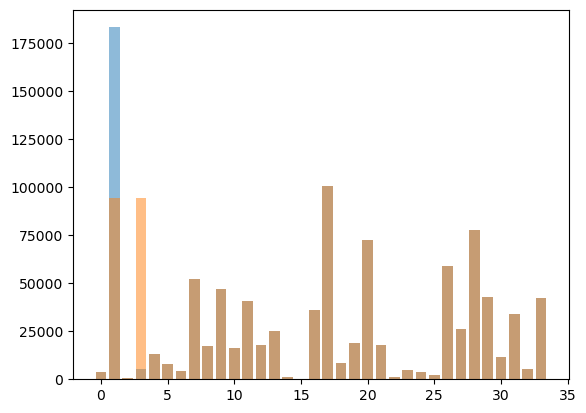

In [184]:
plt.bar(np.arange(results.shape[1]), results[0], alpha=0.5)
plt.bar(np.arange(results.shape[1]), results[-1], alpha=0.5)

In [135]:
np.sum(results[0])

1000000.0000000001

In [136]:
np.sum(results[-1])

999888.7232482631

In [ ]:
def generate_proper_graph_from_balances(balances):
    N = len(balances)

In [4]:
def create_simulation_maxflow2(graph):
    
    num_edges = graph.number_of_edges()
    capacities = list(np.random.randint(1, 10000, num_edges))
    balances = {node: np.random.randint(1, 100000) for node in graph.nodes}
    
    for edge in graph.edges:
        graph.edges[edge]["capacity"] = capacities.pop()
    
    gca = Maxflow2GCA(graph, balance_distribution=balances)
    records = gca.run_simulation(10)
    return records

In [5]:
# Create a Watts-Strogatz graph
n = 1000  # number of nodes
k = 10    # each node is connected to k nearest neighbors in ring topology
p = 0.1   # the probability of rewiring each edge

records = []

graph_1 = nx.barabasi_albert_graph(n, 2, seed=42)
records.append({
    "title": "barabasi_albert_graph",
    "graph": graph_1,
    "records": create_simulation_maxflow2(graph_1)
})


graph_2 = nx.watts_strogatz_graph(n, k, p, seed=42)
records.append({
    "title": "watts_strogatz_graph",
    "graph": graph_2,
    "records": create_simulation_maxflow2(graph_2)
})



                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 10, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (10, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 596.37it/s]

Execution Method: single_proc_exec


AttributeError: 'Graph' object has no attribute 'predecessors'

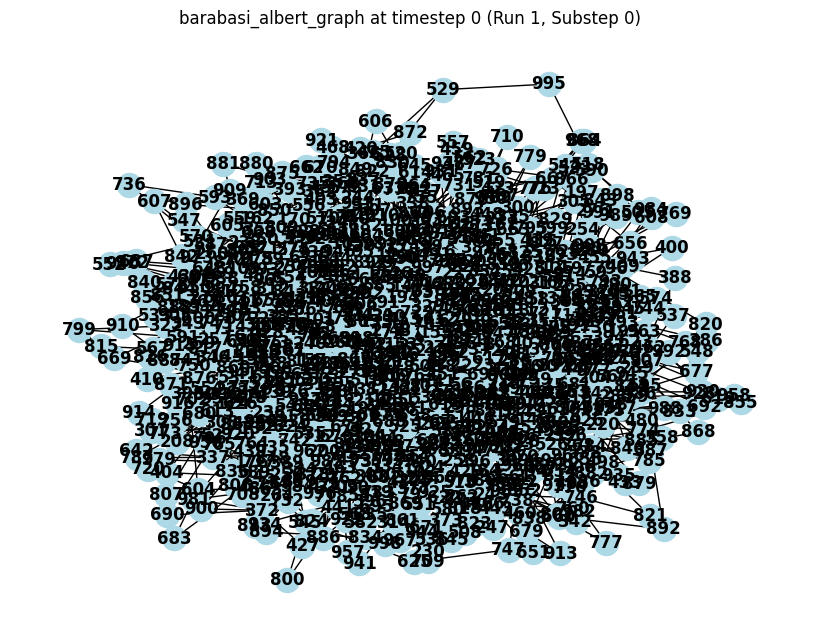

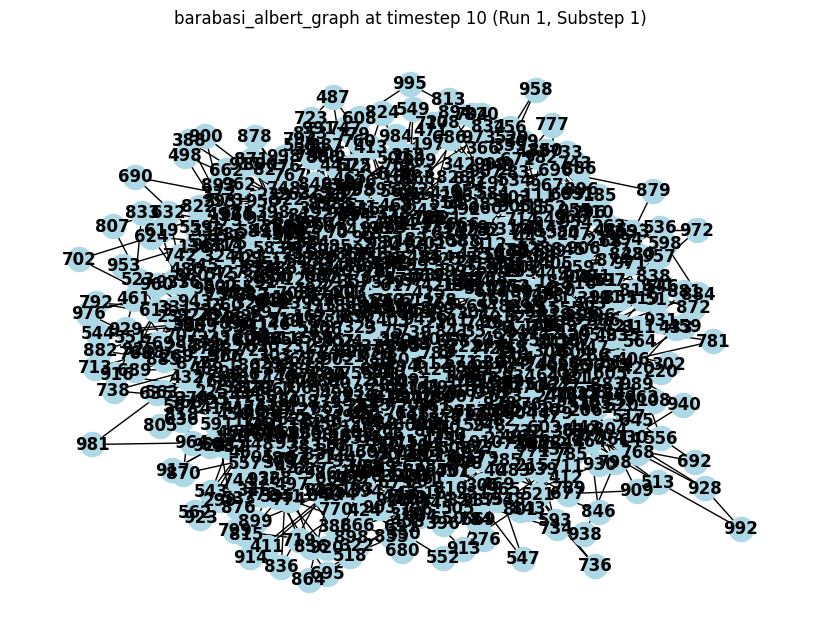

AttributeError: 'Series' object has no attribute 'is_directed'

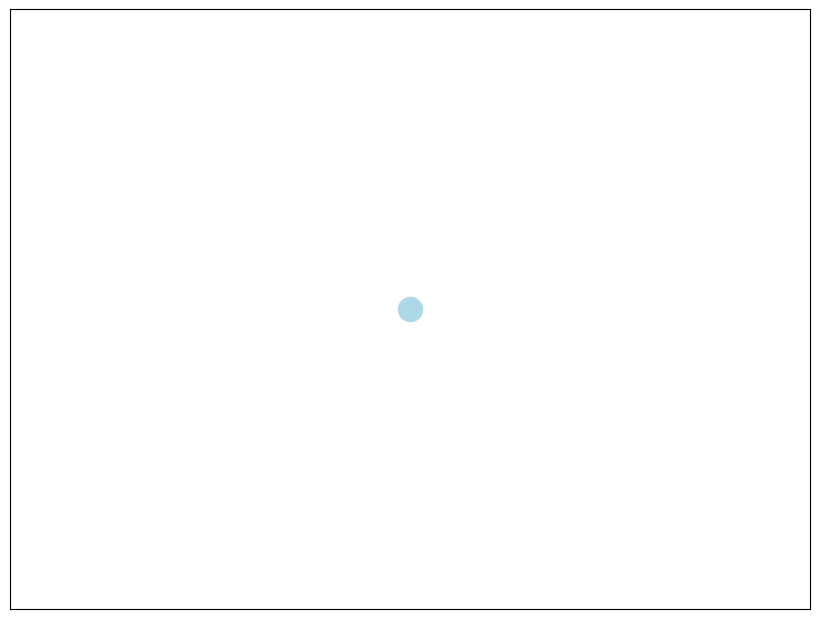

In [63]:

def plot_graph(title, record):
    graph = record['graph']
    plt.figure(figsize=(8, 6))  # Create a new figure for each graph
    nx.draw(graph, with_labels=True, node_color='lightblue', font_weight='bold')
    plt.title(f"{title} at timestep {record['timestep']} (Run {record['run']}, Substep {record['substep']})")
    plt.show()

# Plot each record
for i, record_state in enumerate(records):
    for steps in record_state['records']:
        plot_graph(record_state['title'], steps[0])
        plot_graph(record_state['title'], steps[-1])
    